In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

In [5]:
df = pd.read_csv('EUR_GBP_dataset.csv')

In [23]:
df.set_index('TIME_PERIOD', inplace = True)

# 1. Features 

In [42]:

time = 'TIME_PERIOD'

target = [
        # 'OBS_VALUE', 
        'OBS_VALUE_diff'
        ]

exog_cols = [ 'MONTH', 'WEEK', 'lag_1d', 'lag_2d',
                'rolling_mean_1d', 'rolling_mean_2d',
                'rolling_mean_3d', 'rolling_mean_9d', 'rolling_mean_20d',
                'rolling_mean_60d', 'rolling_std_2d', 'rolling_std_3d',
                'rolling_std_9d', 'rolling_std_20d', 'rolling_std_60d', 'lag_3d',
                'lag_12d']

In [43]:
exog_train = df[exog_cols][:-255] 
exog_val = df[exog_cols][-255:-10] 
exog_test =  df[exog_cols][-10:]

y_train = df[target][:-255] 
y_val = df[exog_cols][-255:-10]
y_test =  df[target][-10:]

# 2. Model: ARIMA

## 2.1 Parameter tuning

In [26]:
import itertools


p = d = q = range(0, 3)

pdq = list(itertools.product(p, d, q))

# seasonal_pdq = [(x[0], x[1], x[2], 12) for x in pdq] 

In [12]:
# Lists to store parameters and AIC values
list_param = []
# list_param_seasonal = []
list_results_aic = []

# # Variables to track the best model
best_aic = float("inf")  # Start with an infinitely large AIC value
best_param = None
# best_param_seasonal = None

In [ ]:
# Loop over each combination of pdq and seasonal_pdq
for param in pdq:
    # for param_seasonal in seasonal_pdq:
        try:
            # Fit the SARIMA model with the specified parameters
            model = ARIMA(y_train,
                            exog=exog_train, 
                            order=param,
                            # seasonal_order=param_seasonal,
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            results = model.fit()

            # Save the parameter combination and its AIC
            list_param.append(param)
            # list_param_seasonal.append(param_seasonal)
            list_results_aic.append(results.aic)
            
            # Print the current combination and its AIC
            print('ARIMA{}x{}12 - AIC:{}'.format(param, 
                                                #  param_seasonal, 
                                                results.aic))
            
            # Update the best model if the current one has a lower AIC
            if results.aic < best_aic:
                best_aic = results.aic
                best_param = param
                # best_param_seasonal = param_seasonal
        except:
            # If the model fails to fit, skip this combination
            continue

In [ ]:
# Print the best model parameters
print("\nBest Model:")
print('ARIMA{}x{}12 - AIC:{}'.format(best_param, 
                                    #  best_param_seasonal, 
                                     best_aic))

In [1]:
# data_array = df[['OBS_VALUE']].values

# avg_errors = []

# for p in range(6):
#     for q in range(6):
#         for i in range(3):
#             errors = []
            
#             tscv = TimeSeriesSplit(test_size=10)

#             for train_index, test_index in tscv.split(data_array):

#                 X_train, X_test = data_array[train_index], data_array[test_index]
#                 X_test_orig = X_test

#                 fcst = []
#                 for step in range(10):

#                     try:
#                         mod = ARIMA(X_train, order=(p,i,q))
#                         res = mod.fit()

#                         fcst.append(res.forecast(step=1))

#                     except:
#                         print('errored')
#                         fcst.append(-9999999.)
                    
#                     X_train = np.concatenate((X_train, X_test[0:1,:]))
#                     X_test = X_test[1:]

#                 errors.append(root_mean_squared_error(X_test_orig, fcst))

#             pq_result = [p, i, q, np.mean(errors)]

#             print(pq_result)
#             avg_errors.append(pq_result)



In [2]:
# avg_errors = pd.DataFrame(avg_errors)
# avg_errors.columns = ['p', 'i', 'q', 'error']
# avg_errors.sort_values('error', ascending= False)

## 2.2 Model Building

In [44]:
best_param = (1, 1, 0)
# best_param_seasonal = (0, 1, 0, 12)

In [46]:
model = ARIMA(y_train,
                exog=exog_train, 
                order=best_param,
                # seasonal_order=best_param_seasonal,
                enforce_stationarity=False,
                enforce_invertibility=False)
results = model.fit()


###########################################
#------------ TRAIN PREDICTION ------------
# #########################################


h = 10 # forecast horizon

# Training
# exog_train_pred = exog_train.iloc[-255:]  # 121 months
 

forecast_res = results.get_forecast(
    steps=h,
    exog=exog_train              # required if you used exog
)

forecast_mean_train = forecast_res.predicted_mean
conf_int = forecast_res.conf_int(alpha=0.05)  # 95% CI

###########################################
#------------ VALIDATION PREDICTION ------------
# #########################################


h = 10 # forecast horizon

# Training
# exog_train_pred = exog_val.iloc[-255:-10]   # 121 months
 

forecast_res = results.get_forecast(
    steps=h,
    exog=exog_val[-h:]              # required if you used exog
)

forecast_mean_val = forecast_res.predicted_mean
conf_int = forecast_res.conf_int(alpha=0.05)  # 95% CI

##########################################
#------------ TEST PREDICTION ------------
# ########################################
  
h = 10  # forecast horizon

forecast_res_test = results.get_forecast(
    steps=h,
    exog=exog_test              # required if you used exog
)

forecast_mean_test = forecast_res_test.predicted_mean
conf_int = forecast_res_test.conf_int(alpha=0.05)  # 95% CI

ValueError: Provided exogenous values are not of the appropriate shape. Required (10, 17), got (5861, 17).

In [ ]:
# Reversing the difference:
anchor =  df[target].iloc[-11] 
final_forecast = forecast_mean_test.cumsum() + anchor

In [ ]:
# root_mean_squared_error, 
# mean_absolute_percentage_error

print(f"MAPE train: {mean_absolute_percentage_error(y_train, forecast_mean_train)}"), 
print(f"MAPE val: {mean_absolute_percentage_error(y_val, forecast_mean_val)}"), 
print(f"MAPE test : {mean_absolute_percentage_error(y_test, forecast_mean_test)}")
print("\n --------------------------------- \n")

print(f"RMSE train: {root_mean_squared_error(y_train, forecast_mean_train)}"), 
print(f"RMSE val: {root_mean_squared_error(y_val[:10], forecast_mean_val)}"), 
print(f"RMSE test : {root_mean_squared_error(y_test, forecast_mean_test)}")

MAPE train: 0.0006437954209155982
MAPE test : 0.0007397337442519105

 --------------------------------- 

RMSE train: 5.949340244633073e-07
RMSE test : 4.7051161833153816e-07


## 2.3 Results analysis

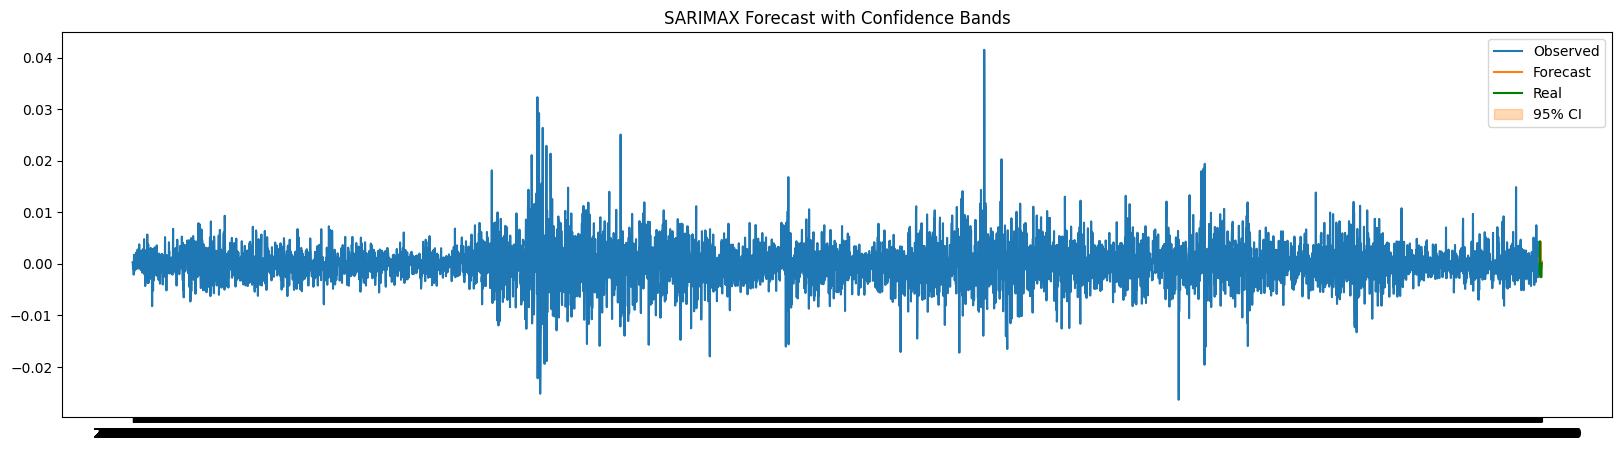

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))

plt.plot(y_train.index, y_train, label='Observed')
plt.plot(forecast_mean_train.index, forecast_mean_train, label='Forecast', color='C1')
plt.plot(y_test.index, y_test, label='Real', color = 'green')

plt.fill_between(
    forecast_mean_train.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='C1',
    alpha=0.3,
    label='95% CI'
)

plt.legend()
plt.title("ARIMAX Forecast with Confidence Bands")
plt.show()


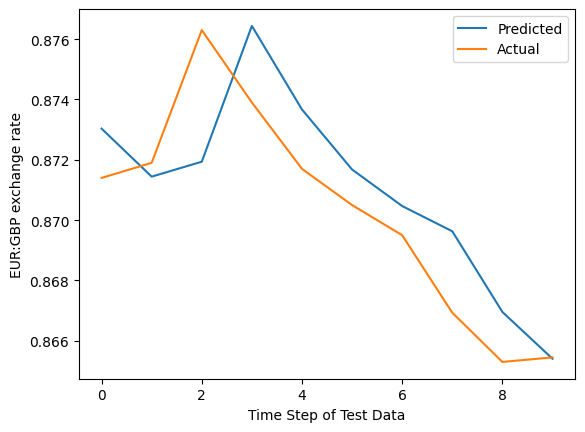

In [7]:
data_array = df[['OBS_VALUE']].values

X_train, X_test = data_array[:-10], data_array[-10:]

X_test_orig = X_test

fcst = []

for step in range(10):

    mod = ARIMA(X_train, order = (4,1,4))
    res = mod.fit()
    fcst.append(res.forecast(step = 1))
    X_train = np.concatenate((X_train, X_test[0:1,:]))
    X_test = X_test[1:]

plt.plot(fcst)
plt.plot(X_test_orig)
plt.legend(['Predicted', 'Actual'])
plt.ylabel('EUR:GBP exchange rate')
plt.xlabel('Time Step of Test Data');
